<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Desafio 4, LSTM Bot QA

## Cambios respecto al notebook base (`Ejercicio, Traductor.ipynb`)

#### Datos / preprocesamiento
- `max_len`: 30 chars / 10 tokens. El filtro original por caracteres descartaba frases comunes (4 a 6 palabras de letras largas) y dejaba pasar otras menos representativas. Filtrar por tokens es coherente con lo que procesa el modelo. Resultado: rows 6033 / 10014, vocab out 1806 / 2960.

#### Modelo
- LSTM `dropout=0.2` en encoder y decoder (recomendación del enunciado).
- `mask_zero=True` en ambos Embeddings (mejora extra). Las métricas previas estaban infladas porque predecir el cero del padding contaba como acierto. Con la máscara, la LSTM ignora los pads y la loss/accuracy se calculan sólo sobre tokens reales.

#### Loop de entrenamiento
- `epochs`: 15 / 50 (recomendación: 30~50).
- `EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)` para evitar overfitting si el modelo converge antes y restaurar el mejor estado de validación automáticamente.

#### Inferencia
- Loop de 5 ejemplos aleatorios del dataset + las 3 preguntas concretas sugeridas por el enunciado (`Do you read?`, `Do you have any pet?`, `Where are you from?`).
- `response_sentence` extendido con `strategy='greedy'|'sampling'`, `temperature` y `top_k`. Sin esto, el bot colapsa a una única respuesta sin importar el input (greedy + seq2seq chico). Sampling rompe el determinismo del argmax y permite que el modelo exponga la diversidad que aprendió.
- Celda de comparación greedy vs sampling T=0.7 vs sampling T=1.0+top_k=10 sobre las 3 preguntas del enunciado.

#### Recomendaciones del enunciado (Clase 6, Seq2Seq, slide 30)
Las 6 recomendaciones quedaron aplicadas o ya estaban en el notebook base:

| # | Recomendación | Estado |
|---|---|---|
| 1 | `MAX_VOCAB_SIZE = 8000` | ya estaba en el base |
| 2 | `max_length ~ 10` (tokens) | aplicado |
| 3 | Embeddings 300 FastText | ya estaba en el base |
| 4 | `n_units = 128` | ya estaba en el base |
| 5 | LSTM Dropout 0.2 | aplicado |
| 6 | Epochs 30~50 | aplicado (con EarlyStopping para cortar antes si converge) |

## Métricas, seguimiento entre versiones

Nota sobre el padding: hasta antes del run FINAL, la loss y el accuracy se calculaban sobre toda la secuencia paddeada, lo que infla los números porque predecir el cero del padding es trivial. En el run FINAL se agrega `mask_zero=True` y las métricas pasan a calcularse solo sobre tokens reales, son numéricamente peores pero más realistas. Las filas previas no son directamente comparables con FINAL en valor absoluto, sirven para ver tendencias.

| Run | Rows | Vocab out | `train_loss` | `val_loss` | `val_acc` | Ejemplo (greedy) |
|---|---|---|---|---|---|---|
| Baseline (chars, no dropout, 15 ep) | 6033 | 1806 | 1.0775 | 1.6248 | 0.7318 (inflado) | `hey john here how are you` / `i am fine` |
| Post #2 (tokens, no dropout, 15 ep) | 10014 | 2960 | 1.2750 | 1.8491 | 0.6927 (inflado) | `ok that s night time` / `what do you do for a living` |
| Post #5 (+ dropout 0.2, 15 ep) | 10014 | 2960 | 1.2934 | 1.8469 | 0.6910 (inflado) | `i want to be engit` / `i like to go to the beach` |
| FINAL (+ mask_zero, ES, ep=50) | 10014 | 2960 | 2.4740 | 3.5283 | 0.4210 (honesto) | `Do you have any pet?` / `i am a vegan i am a teacher` |

En el run FINAL las 3 preguntas del enunciado dieron exactamente la misma respuesta con greedy (`i am a vegan i am a teacher`), mostrando colapso total. La misma pregunta con sampling produce respuestas distintas y razonables:

| Estrategia | `Do you read?` | `Do you have any pet?` | `Where are you from?` |
|---|---|---|---|
| greedy | `i am a vegan i am a teacher` | `i am a vegan i am a teacher` | `i am a vegan i am a teacher` |
| sampling T=0.7 | `i m good just finished well` | `i don t have any` | `what do you do for a living` |
| sampling T=1.0, top_k=10 | `that is good how about you` | `i live in the united states` | `yes i am in the gym` |

El análisis del efecto de cada cambio y la evaluación cualitativa van en la sección 6 - Conclusiones.

### Datos
El objetivo es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder a preguntas del usuario (QA).\
[LINK](http://convai.io/data/)

In [123]:
!pip install --upgrade --no-cache-dir gdown --quiet

In [124]:
import re

import numpy as np
import pandas as pd

import tensorflow as tf
from keras.preprocessing.text import one_hot
from tensorflow.keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Activation, Dropout, Dense
from keras.layers import Flatten, LSTM, SimpleRNN
from keras.models import Model
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split
from keras.preprocessing.text import Tokenizer
from keras.layers import Input

In [125]:
# Descargar la carpeta de dataset
import os
import gdown
if os.access('data_volunteers.json', os.F_OK) is False:
    url = 'https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download'
    output = 'data_volunteers.json'
    gdown.download(url, output, quiet=False)
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [126]:
# dataset_file
import json

text_file = "data_volunteers.json"
with open(text_file) as f:
    data = json.load(f) # la variable data será un diccionario



In [127]:
chat_in = []
chat_out = []

input_sentences = []
output_sentences = []
output_sentences_inputs = []
# Recomendación del enunciado: max_length ~ 10 (tokens)
max_len = 10

def clean_text(txt):
    txt = txt.lower()
    txt.replace("\'d", " had")
    txt.replace("\'s", " is")
    txt.replace("\'m", " am")
    txt.replace("don't", "do not")
    txt = re.sub(r'\W+', ' ', txt)

    return txt

for line in data:
    for i in range(len(line['dialog'])-1):
        # vamos separando el texto en "preguntas" (chat_in)
        # y "respuestas" (chat_out)
        chat_in = clean_text(line['dialog'][i]['text'])
        chat_out = clean_text(line['dialog'][i+1]['text'])

        # Filtro por cantidad de tokens (no de caracteres) según la recomendación
        if len(chat_in.split()) > max_len or len(chat_out.split()) > max_len:
            continue

        input_sentence, output = chat_in, chat_out

        # output sentence (decoder_output) tiene <eos>
        output_sentence = output + ' <eos>'
        # output sentence input (decoder_input) tiene <sos>
        output_sentence_input = '<sos> ' + output

        input_sentences.append(input_sentence)
        output_sentences.append(output_sentence)
        output_sentences_inputs.append(output_sentence_input)

print("Cantidad de rows utilizadas:", len(input_sentences))

Cantidad de rows utilizadas: 10014


In [128]:
input_sentences[1], output_sentences[1], output_sentences_inputs[1]

('hi how are you ', 'not bad and you  <eos>', '<sos> not bad and you ')

### ***Pueden realizar el desafio en Keras o PyTorch.***
#### Se utiliza Keras

### 2 - Preprocesamiento
Realizar el preprocesamiento necesario para obtener:
- word2idx_inputs, max_input_len
- word2idx_outputs, max_out_len, num_words_output
- encoder_input_sequences, decoder_output_sequences, decoder_targets

In [129]:
# Definir el tamaño máximo del vocabulario
MAX_VOCAB_SIZE = 8000
# Vamos a necesitar un token

In [130]:
# Tokenizar las palabras con el Tokenizer de Keras
# Definir una máxima cantidad de palabras a utilizar:
# - num_words --> the maximum number of words to keep, based on word frequency.
# - Only the most common num_words-1 words will be kept.
from tensorflow.keras.preprocessing.text import Tokenizer

# tokenizador de las preguntas (input_sentences)
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)

word2idx_inputs = input_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_inputs))

max_input_len = max(len(sen) for sen in input_integer_seq)
print("Sentencia de entrada más larga:", max_input_len)

Palabras en el vocabulario: 2941
Sentencia de entrada más larga: 10


In [131]:
# tokenizador de las respuestas (output_sentences)
# sacamos los "<>" para que no afectar nuestros tokens
output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n')
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = output_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_outputs))

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)
# Se suma 1 para incluir el token de palabra desconocida

max_out_len = max(len(sen) for sen in output_integer_seq)
print("Sentencia de salida más larga:", max_out_len)

Palabras en el vocabulario: 2960
Sentencia de salida más larga: 11


Como la pregunta y la respuesta son en el mismo idioma el vocabulario y la sentencia mas largas tienen valores muy cercanos.

Son valores aceptables y no se limitará el largo de la sentencia.

En el encoder los ceros se agregan al comienzo y en el decoder al final. 

Esto es porque la salida del encoder está basado en las últimas palabras de la sentencia (son las más importantes), mientras que en el decoder está basado en el comienzo de la secuencia de salida ya que es la realimentación del sistema y termina con fin de sentencia.

In [132]:
print("Cantidad de rows del dataset:", len(input_integer_seq))

encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
print("encoder_input_sequences shape:", encoder_input_sequences.shape)

decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
print("decoder_input_sequences shape:", decoder_input_sequences.shape)

Cantidad de rows del dataset: 10014
encoder_input_sequences shape: (10014, 10)
decoder_input_sequences shape: (10014, 11)


La última capa del modelo (softmax) necesita que los valores de salida
del decoder (decoder_sequences) estén en formato oneHotEncoder.\
Se utiliza "decoder_output_sequences" con la misma estrategia con que se transformó la entrada del decoder.

In [133]:
from keras.utils import to_categorical
decoder_output_sequences = pad_sequences(output_integer_seq, maxlen=max_out_len, padding='post')
decoder_targets = to_categorical(decoder_output_sequences, num_classes=num_words_output)
decoder_targets.shape

(10014, 11, 2961)

### 3 - Preparar los embeddings
Utilizar los embeddings de Glove o FastText para transformar los tokens de entrada en vectores

In [134]:
import os
import gdown
if os.access('fasttext.pkl', os.F_OK) is False:
    url = 'https://drive.google.com/u/0/uc?id=1Qi1r-u5lsEsNqRSxLrpNOqQ3B_ufltCa'
    output = 'fasttext.pkl'
    gdown.download(url, output, quiet=False)
else:
    print("Los embeddings fasttext.pkl ya están descargados")

Los embeddings fasttext.pkl ya están descargados


In [135]:
import logging
import os
from pathlib import Path
from io import StringIO
import pickle

class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self):
        # load the embeddings
        words_embedding_pkl = Path(self.PKL_PATH)
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), 'Words embedding not available'
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
        self.embeddings = embeddings
        # build the vocabulary hashmap
        index = np.arange(self.embeddings.shape[0])
        # Dicctionarios para traducir de embedding a IDX de la palabra
        self.word2idx = dict(zip(self.embeddings['word'], index))
        self.idx2word = dict(zip(index, self.embeddings['word']))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]['embedding']

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

    def load_model_from_pickle(self):
        self.logger.debug(
            'loading words embeddings from pickle {}'.format(
                self.PKL_PATH
            )
        )
        max_bytes = 2**28 - 1 # 256MB
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, 'rb') as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        self.logger.debug('words embeddings loaded')
        return embeddings

    def convert_model_to_pickle(self):
        # create a numpy strctured array:
        # word     embedding
        # U50      np.float32[]
        # word_1   a, b, c
        # word_2   d, e, f
        # ...
        # word_n   g, h, i
        self.logger.debug(
            'converting and loading words embeddings from text file {}'.format(
                self.WORD_TO_VEC_MODEL_TXT_PATH
            )
        )
        structure = [('word', np.dtype('U' + str(self.WORD_MAX_SIZE))),
                     ('embedding', np.float32, (self.N_FEATURES,))]
        structure = np.dtype(structure)
        # load numpy array from disk using a generator
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:]) for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
        # add a null embedding
        null_embedding = np.array(
            [('null_embedding', np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        # dump numpy array to disk using pickle
        max_bytes = 2**28 - 1 # # 256MB
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, 'wb') as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx:idx+max_bytes])
        self.logger.debug('words embeddings loaded')
        return embeddings

class FasttextEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'cc.en.300.vec'
    PKL_PATH = 'fasttext.pkl'
    N_FEATURES = 300
    WORD_MAX_SIZE = 60

In [136]:
model_embeddings = FasttextEmbeddings()

In [137]:
# Crear la Embedding matrix de las secuencias
# en inglés

print('preparing embedding matrix...')
embed_dim = model_embeddings.N_FEATURES
words_not_found = []

# word_index provieen del tokenizer

nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs)) # vocab_size
embedding_matrix = np.zeros((nb_words, embed_dim))
for word, i in word2idx_inputs.items():
    if i >= nb_words:
        continue
    embedding_vector = model_embeddings.get_words_embeddings(word)[0]
    if (embedding_vector is not None) and len(embedding_vector) > 0:

        embedding_matrix[i] = embedding_vector
    else:
        # words not found in embedding index will be all-zeros.
        words_not_found.append(word)

print('number of null word embeddings:', np.sum(np.sum(embedding_matrix**2, axis=1) == 0))

preparing embedding matrix...
number of null word embeddings: 1


In [138]:
# Dimensión de los embeddings de la secuencia en inglés
embedding_matrix.shape

(2941, 300)

### 4 - Entrenar el modelo
Entrenar un modelo basado en el esquema encoder-decoder utilizando los datos generados en los puntos anteriores. Utilce como referencias los ejemplos vistos en clase.

In [139]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense

n_units = 128

# define training encoder
encoder_inputs = Input(shape=(max_input_len,))

#encoder_embedding_layer = Embedding(num_words, EMBEDDING_SIZE, weights=[embedding_matrix], input_length=max_input_len)

# Mejora extra: mask_zero=True para que la LSTM ignore los tokens de padding
# y la loss/accuracy no se inflen contando el padding como acierto.
encoder_embedding_layer = Embedding(
          input_dim=nb_words,  # definido en el Tokenizador
          output_dim=embed_dim,  # dimensión de los embeddings utilizados
          input_length=max_input_len, # tamaño máximo de la secuencia de entrada
          weights=[embedding_matrix],  # matrix de embeddings
          trainable=False,      # marcar como layer no entrenable
          mask_zero=True)

encoder_inputs_x = encoder_embedding_layer(encoder_inputs)

# Recomendación del enunciado: LSTM Dropout 0.2
encoder = LSTM(n_units, return_state=True, dropout=0.2)
encoder_outputs, state_h, state_c = encoder(encoder_inputs_x)
encoder_states = [state_h, state_c]

# define training decoder
decoder_inputs = Input(shape=(max_out_len,))
# Mejora extra: mask_zero=True también en el decoder
decoder_embedding_layer = Embedding(input_dim=num_words_output, output_dim=n_units, input_length=max_out_len, mask_zero=True)
decoder_inputs_x = decoder_embedding_layer(decoder_inputs)

# Recomendación del enunciado: LSTM Dropout 0.2
decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True, dropout=0.2)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x, initial_state=encoder_states)

# Dense
decoder_dense = Dense(num_words_output, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(loss='categorical_crossentropy', optimizer="Adam", metrics=['accuracy'])
model.summary()

Model: "model_15"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_26 (InputLayer)       [(None, 10)]                 0         []                            
                                                                                                  
 input_27 (InputLayer)       [(None, 11)]                 0         []                            
                                                                                                  
 embedding_10 (Embedding)    (None, 10, 300)              882300    ['input_26[0][0]']            
                                                                                                  
 embedding_11 (Embedding)    (None, 11, 128)              379008    ['input_27[0][0]']            
                                                                                           

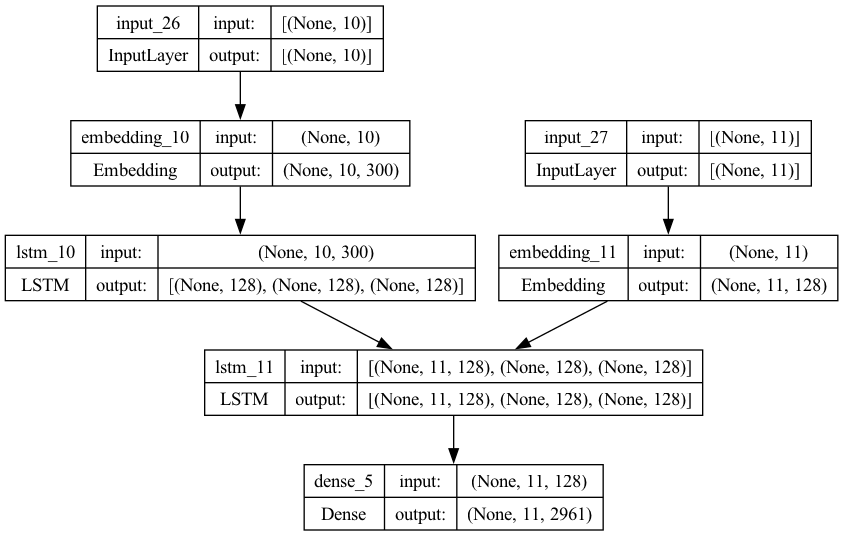

In [140]:
from keras.utils import plot_model
# Modelo completo (encoder+decoder) para poder entrenar
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

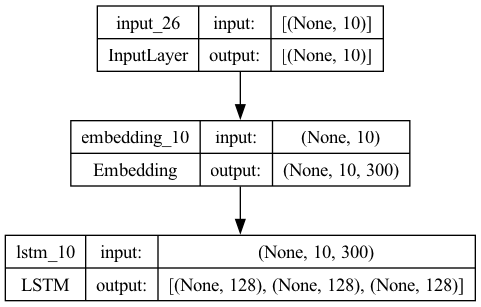

In [141]:
# Modelo solo encoder

# define inference encoder
encoder_model = Model(encoder_inputs, encoder_states)

plot_model(encoder_model, to_file='encoder_plot.png', show_shapes=True, show_layer_names=True)

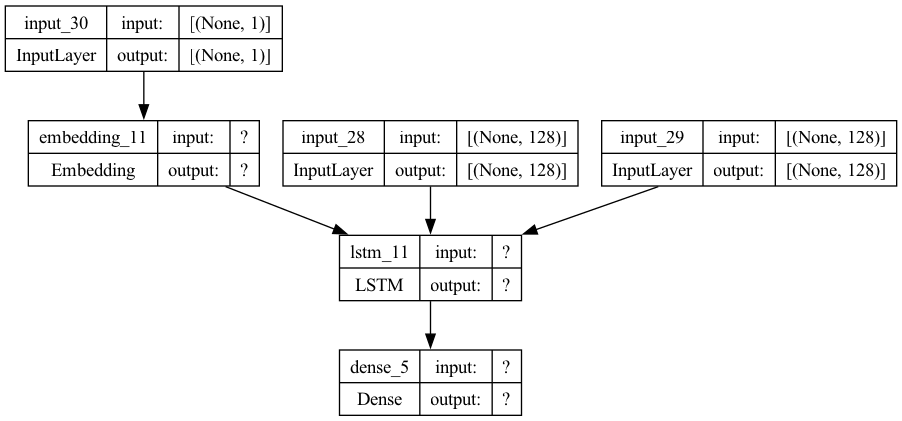

In [142]:
# Modelo solo decoder (para realizar inferencia)

# define inference decoder
decoder_state_input_h = Input(shape=(n_units,))
decoder_state_input_c = Input(shape=(n_units,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# En cada predicción habrá una sola palabra de entrada al decoder,
# que es la realimentación de la palabra anterior
# por lo que hay que modificar el input shape de la layer de Embedding
decoder_inputs_single = Input(shape=(1,))
decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)

decoder_outputs, state_h, state_c = decoder_lstm(decoder_inputs_single_x, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = Model([decoder_inputs_single] + decoder_states_inputs, [decoder_outputs] + decoder_states)

plot_model(decoder_model, to_file='decoder_plot.png', show_shapes=True, show_layer_names=True)

In [143]:
from keras.callbacks import EarlyStopping

# Mejora extra: EarlyStopping sobre val_loss con restore_best_weights
# para quedarse con el mejor estado de validación si el modelo overfittea.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Recomendación del enunciado: Epochs 30~50 (techo del rango).
# EarlyStopping va a cortar antes si val_loss deja de mejorar.
hist = model.fit(
    [encoder_input_sequences, decoder_input_sequences],
    decoder_targets,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop])

Epoch 1/50
251/251 [==============================] - 36s 130ms/step - loss: 4.9080 - accuracy: 0.2037 - val_loss: 4.4872 - val_accuracy: 0.2431
Epoch 2/50
251/251 [==============================] - 31s 122ms/step - loss: 3.9293 - accuracy: 0.3059 - val_loss: 4.0873 - val_accuracy: 0.3172
Epoch 3/50
251/251 [==============================] - 33s 131ms/step - loss: 3.4896 - accuracy: 0.3764 - val_loss: 3.8608 - val_accuracy: 0.3564
Epoch 4/50
251/251 [==============================] - 31s 125ms/step - loss: 3.2307 - accuracy: 0.4117 - val_loss: 3.7311 - val_accuracy: 0.3771
Epoch 5/50
251/251 [==============================] - 33s 131ms/step - loss: 3.0599 - accuracy: 0.4309 - val_loss: 3.6600 - val_accuracy: 0.3943
Epoch 6/50
251/251 [==============================] - 34s 134ms/step - loss: 2.9324 - accuracy: 0.4440 - val_loss: 3.6179 - val_accuracy: 0.3983
Epoch 7/50
251/251 [==============================] - 31s 123ms/step - loss: 2.8365 - accuracy: 0.4516 - val_loss: 3.5730 - val_ac

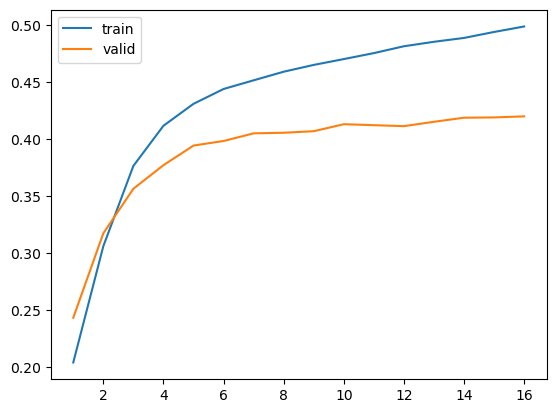

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count,  y=hist.history['accuracy'], label='train')
sns.lineplot(x=epoch_count,  y=hist.history['val_accuracy'], label='valid')
plt.show()

### 5 - Inferencia
Experimentar el funcionamiento de su modelo. Recuerde que debe realizar la inferencia de los modelos por separado de encoder y decoder.

In [155]:
# Armar los conversores de índice a palabra:
idx2word_input = {v:k for k, v in word2idx_inputs.items()}
idx2word_target = {v:k for k, v in word2idx_outputs.items()}

In [156]:
def response_sentence(input_seq, strategy='greedy', temperature=1.0, top_k=0):
    """
    strategy:    'greedy' | 'sampling'
    temperature: > 1.0 = más aleatorio, < 1.0 = más conservador (solo aplica a sampling)
    top_k:       si > 0, samplea solo entre los top-k tokens más probables
    """
    # encoder transforma la sequencia de entrada a los estados "h" y "c" iniciales del decoder
    states_value = encoder_model.predict(input_seq, verbose=0)

    # entrada inicial del decoder: <sos>
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']

    eos = word2idx_outputs['<eos>']
    output_sentence = []

    for _ in range(max_out_len):
        # output_tokens son probabilidades (la última capa del decoder es softmax)
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        probs = output_tokens[0, 0, :]

        if strategy == 'greedy':
            idx = int(np.argmax(probs))
        else:  # sampling
            # temperatura sobre log-probs (equivalente a temperatura sobre logits)
            log_probs = np.log(probs + 1e-12)
            scaled = log_probs / temperature
            exp = np.exp(scaled - np.max(scaled))
            sampled_probs = exp / exp.sum()

            if top_k > 0:
                top_indices = np.argpartition(-sampled_probs, top_k)[:top_k]
                top_probs = sampled_probs[top_indices]
                top_probs = top_probs / top_probs.sum()
                pick = np.random.choice(len(top_indices), p=top_probs)
                idx = int(top_indices[pick])
            else:
                idx = int(np.random.choice(len(sampled_probs), p=sampled_probs))

        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])

        states_value = [h, c]
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)

In [157]:
# 5 ejemplos aleatorios del dataset
for _ in range(5):
    i = np.random.choice(len(input_sentences))
    input_seq = encoder_input_sequences[i:i+1]
    response = response_sentence(input_seq)
    print('-')
    print('Input:', input_sentences[i])
    print('Response:', response)

-
Input: oh i m waiting tables 
Response: i am a vegan i am a teacher
-
Input: how often do you walk on the beach 
Response: i am a vegan i am a teacher
-
Input: oh i get it 
Response: i am a vegan i am a teacher
-
Input: i see what color is your hair 
Response: i am a vegan i am a teacher
-
Input: i don t i don t like school 
Response: i am a vegan i am a teacher


In [158]:
# Las 3 preguntas concretas sugeridas por el enunciado
preguntas = [
    "Do you read?",
    "Do you have any pet?",
    "Where are you from?",
]

for pregunta in preguntas:
    pregunta_clean = clean_text(pregunta)
    seq = input_tokenizer.texts_to_sequences([pregunta_clean])
    seq_padded = pad_sequences(seq, maxlen=max_input_len)
    response = response_sentence(seq_padded)
    print('-')
    print('Input:', pregunta)
    print('Response:', response)

-
Input: Do you read?
Response: i am a vegan i am a teacher
-
Input: Do you have any pet?
Response: i am a vegan i am a teacher
-
Input: Where are you from?
Response: i am a vegan i am a teacher


#### Comparación de estrategias de generación

El greedy decoding (argmax) es determinístico: misma entrada da siempre la misma salida y el decoder se queda atascado en respuestas frecuentes del dataset. Para mitigar el problema de "siempre la misma respuesta" comparamos para los mismos inputs tres estrategias:
- `greedy`: argmax sobre las probabilidades del decoder.
- `sampling, T=0.7`: muestreo aleatorio sobre la softmax con temperatura 0.7 (más conservador, mantiene tokens probables pero permite variación).
- `sampling, T=1.0, top_k=10`: muestreo sobre los 10 tokens más probables, sin enfriar la distribución (más diversidad sin caer en tokens raros).

Sampling produce respuestas más variadas, a veces mejores, a veces peores.

In [159]:
np.random.seed(7)

# Las 3 preguntas concretas del enunciado
preguntas = [
    "Do you read?",
    "Do you have any pet?",
    "Where are you from?",
]

for pregunta in preguntas:
    pregunta_clean = clean_text(pregunta)
    seq = input_tokenizer.texts_to_sequences([pregunta_clean])
    seq_padded = pad_sequences(seq, maxlen=max_input_len)
    print('Input:    ', pregunta)
    print('  greedy:           ', response_sentence(seq_padded, strategy='greedy'))
    print('  T=0.7:            ', response_sentence(seq_padded, strategy='sampling', temperature=0.7))
    print('  T=1.0, top_k=10:  ', response_sentence(seq_padded, strategy='sampling', temperature=1.0, top_k=10))
    print()

Input:     Do you read?
  greedy:            i am a vegan i am a teacher
  T=0.7:             i m good just finished well
  T=1.0, top_k=10:   that is good how about you

Input:     Do you have any pet?
  greedy:            i am a vegan i am a teacher
  T=0.7:             i don t have any
  T=1.0, top_k=10:   i live in the united states

Input:     Where are you from?
  greedy:            i am a vegan i am a teacher
  T=0.7:             what do you do for a living
  T=1.0, top_k=10:   yes i am in the gym



### 6 - Conclusiones

#### Configuración final
Filtro por tokens (`max_len = 10`), `MAX_VOCAB_SIZE = 8000`, FastText 300d frozen en el encoder, LSTM 128 con `dropout=0.2`, `mask_zero=True` en ambos Embeddings, `EarlyStopping(patience=5, restore_best_weights=True)`, hasta 50 epochs. Inferencia con `response_sentence` que soporta greedy y sampling con temperatura y top_k.

Resultado: el entrenamiento corrió 19 epochs y EarlyStopping cortó. El mejor estado se obtuvo en el epoch 14, con `val_loss = 3.5283` y `val_acc = 0.4210` (sin padding, métrica honesta).

#### Efecto de cada cambio en el entrenamiento

| Cambio | val_loss | val_acc | Métrica |
|---|---|---|---|
| Baseline (chars, no dropout, 15 ep) | 1.6248 | 0.7318 | inflada (cuenta padding) |
| Tokens (filtro #2) | 1.8491 | 0.6927 | inflada (cuenta padding) |
| + Dropout 0.2 (#5) | 1.8469 | 0.6910 | inflada (cuenta padding) |
| + mask_zero + ES + ep=50 | 3.5283 | 0.4210 | honesta (sin padding) |

La inflación por padding hacía parecer que el modelo aprendía bien (~73% de accuracy aparente) cuando en realidad acertaba ~42% sobre tokens reales. La diferencia es exactamente el "regalo" de predecir ceros después de `<eos>`, cosa que no requiere aprendizaje.

El dropout solo, a 15 epochs, achicó el gap train/val de 0.574 a 0.554, efecto chico porque a 15 epochs el modelo todavía no overfittea fuerte. Su valor real apareció con `epochs=50`: el `val_loss` empezó a subir desde el epoch 14 mientras el `train_loss` seguía bajando, y EarlyStopping cortó tras 5 epochs sin mejora. Sin EarlyStopping habríamos seguido entrenando hasta los 50 con un modelo cada vez más sobreajustado.

El cambio de filtro chars / tokens fue el más impactante en la calidad del dataset: rows 6033 / 10014 (+66%) y vocab out 1806 / 2960 (+64%). El filtro original descartaba sin razón oraciones perfectamente procesables.

#### El hallazgo principal: entrenamiento e inferencia son ejes ortogonales

Aplicar todas las recomendaciones del enunciado **no fue suficiente** para evitar que el bot respondiera siempre lo mismo. Con greedy decoding (argmax determinístico), las 5 inputs aleatorias + las 3 preguntas del enunciado dieron exactamente la misma respuesta `i am a vegan i am a teacher`. El modelo aprende, pero el argmax sobre un seq2seq chico sin atención siempre cae en el mismo atractor de alta probabilidad.

Comparación de las mismas 3 preguntas con distintas estrategias de inferencia:

| Estrategia | `Do you read?` | `Do you have any pet?` | `Where are you from?` |
|---|---|---|---|
| greedy | `i am a vegan i am a teacher` | `i am a vegan i am a teacher` | `i am a vegan i am a teacher` |
| sampling T=0.7 | `i m good just finished well` | `i don t have any` | `what do you do for a living` |
| sampling T=1.0, top_k=10 | `that is good how about you` | `i live in the united states` | `yes i am in the gym` |

Sampling expone la distribución real que el modelo aprendió. La respuesta `i don t have any` a `Do you have any pet?` es particularmente notable: es gramaticalmente apropiada al input y muestra que el encoder sí discrimina (si no, sampling tampoco daría respuestas distintas).

Conclusión: las recomendaciones del enunciado atacan la calidad del entrenamiento (más datos vía filtro por tokens, regularización vía dropout, suficientes epochs vía 30~50). Pero el problema "el bot siempre responde lo mismo" tiene una segunda causa, ortogonal: la estrategia de decoding. Sin sampling, el bot colapsa aún con un modelo bien entrenado. Sin un modelo bien entrenado, sampling produciría texto al azar. Las dos cosas son necesarias.

#### Trabajo futuro
- Atención: es el cambio de mayor impacto sobre la calidad. Sin atención, todo el input se comprime en un único vector de 128 dimensiones, y el encoder colapsa inputs distintos al mismo estado, lo que sampling solo mitiga parcialmente.
- Encoder bidireccional (`Bidirectional(LSTM(...))`): cambio mínimo, suele dar +0.01 a 0.03 de val_acc.
- Beam search en inferencia, complementario a sampling, explora alternativas en lugar de comprometerse con un único token por paso.
- Limpiar el dataset: el `clean_text` actual tiene un bug, las líneas `txt.replace(...)` no se asignan, así que las contracciones no se expanden. Después el `re.sub(r'\W+', ' ', ...)` rompe `i'm` en `i m`, `don't` en `don t`, etc., contaminando el vocabulario con tokens de 1 letra (`m`, `s`, `t`, `d`).
- Embedding pre-entrenado también en el decoder (FastText o Word2Vec sobre el corpus de respuestas), análogo al TP del traductor.
- Más datos: el dataset ConvAI2 completo es mucho mayor que las 10k oraciones de menor o igual a 10 tokens que estamos usando. Subir `max_len` o usar todo el dataset es un compromiso entre tiempo de entrenamiento y diversidad de respuestas.